# Intraday Seasonality — Cross-Market & EUREX Comparison

**Research Axis 1 — Descriptive cross-market microstructure metrics**  
**Date:** 2026-04-03

---

## Context

Intraday seasonality refers to the systematic, recurring patterns in market activity within a trading session. Activity is not uniform across the day — virtually all liquid futures markets exhibit well-documented intraday patterns: elevated volume at the open, a trough in mid-session, and a pick-up near the close. This U-shaped (or J-shaped) profile is documented across asset classes and venues in the microstructure literature (Admati & Pfleiderer, 1988; Wood, McInish & Ord, 1985).

Understanding these patterns is a **prerequisite for any intraday signal construction**:
- A signal that appears to predict price at 09:35 ET may simply be capturing the open auction effect, not genuine alpha.
- Spread-based transaction cost models must account for intraday variation — using a daily average spread is a mis-specification.
- Depth dynamics determine the realistic fill size at each point in the session, which conditions order sizing in execution algorithms.

We analyze four products representing three geographic zones and three liquidity tiers:
- **ES** (E-mini S&P 500, CME, n=23 days) — highest global liquidity, US zone
- **FDAX** (DAX Future, Eurex, n=21 days) — high liquidity, European zone
- **NIY** (Nikkei 225 JPY, CME, n=258 days) — medium liquidity, Asian zone (OSE session)
- **HSI** (Hang Seng Future, HKEX, n=17 days) — medium liquidity, Asian zone (with lunch break)

A second section zooms into the **EUREX liquidity gradient**: FDAX, FESX, and FSMI on the same axis — three products sharing the same session window (07:00–21:00 UTC) but with very different microstructure profiles.

## Metrics

For each product, we compute the average intraday profile over all available RTH trading days, binned at **30-minute intervals**:

| Metric | Source | Unit | Definition |
|--------|--------|------|------------|
| **Volume** | MBO | trades / 30-min bin | Count of `action='TRADE'` events |
| **OTR** | MBO | dimensionless | `(n_add + n_modify) / n_fill` — per Eurex definition |
| **Spread** | MBP-1 | ticks | `(ask_px_00 - bid_px_00) / tick_size` — BBO changes only |
| **Depth** | MBP-1 | contracts | `bid_sz_00 + ask_sz_00` at best level — BBO changes only |

## Implementation Notes

- **Two data sources per day:** MBO for volume and OTR, MBP-1 for spread and depth. RTH filtering applied at load time via `dr.get_mbo_rth()` / `dr.get_mbp1_rth()`.
- **BBO change filter:** spread and depth are computed only on rows where the best bid or ask actually changed. MBP-1 emits a snapshot after every MBO event — without this filter, unchanged states would be over-represented during periods of intense quoting behind the best level.
- **OTR definition:** numerator = `ADD + MODIFY` (each MODIFY counts as one order submission regardless of the underlying Delete+Add mechanics). Denominator = `FILL` (passive executions), not `TRADE` (price print). This is the Eurex regulatory definition, applied consistently cross-market.
- **Cross-day aggregation:** each day produces a per-bin profile, averaged via `aggregate_*_profiles()`. Shaded bands = ±1 cross-day standard deviation (day-to-day variability, not within-day noise).
- **Dual time axis:** UTC (bottom) + local exchange timezone DST-aware via `pytz` (top).
- **Memory:** tick data loaded one day at a time, released after per-day aggregation. Peak RAM ≈ one day ES MBO + MBP-1 (~800 MB).

In [1]:
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
import pytz

import DestinyResearch as dr
from DestinyResearch.features.spread import compute_spread, aggregate_spread_profiles
from DestinyResearch.features.volume import compute_volume, aggregate_volume_profiles
from DestinyResearch.features.depth  import compute_depth,  aggregate_depth_profiles
from DestinyResearch.features.otr    import compute_otr,    aggregate_otr_profiles

# --- Output directory
FIG_DIR = Path("../../reports/figures/04_intraday_seasonality")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- Plot style
sns.set_theme(style="whitegrid", font_scale=1.05)

# One color per product — consistent across all figures
PRODUCT_COLORS = {
    "ES":   "#2c5f8a",   # dark blue
    "FDAX": "#e07b39",   # orange
    "FESX": "#e8b84b",   # amber
    "FSMI": "#6aab6a",   # green
    "NIY":  "#9b59b6",   # purple
    "HSI":  "#c0392b",   # red
}

# --- Parameters
BIN_MINUTES     = 30
SHOW_CI         = True    # show confidence intervals (cross-day std)
CI_ALPHA        = 0.15    # shading opacity for confidence band
MIN_OBS_PER_BIN = 10      # minimum n_obs to include a bin (filters edge artefacts)

# Products and their date ranges (all available RTH data)
PRODUCT_CONFIG = {
    "ES":   {"start": "2025-10-01", "end": "2025-11-01", "session": "default"},
    "FDAX": {"start": "2025-05-01", "end": "2025-06-01", "session": "default"},
    "FESX": {"start": "2025-05-01", "end": "2025-06-01", "session": "default"},
    "FSMI": {"start": "2025-05-01", "end": "2025-06-01", "session": "default"},
    "NIY":  {"start": "2025-01-01", "end": "2025-12-31", "session": "asia"},
    "HSI":  {"start": "2026-02-01", "end": "2026-02-28", "session": "default"},
}

print(f"Bin size: {BIN_MINUTES} min | Confidence intervals: {SHOW_CI}")
print(f"Products configured: {list(PRODUCT_CONFIG.keys())}")

Bin size: 30 min | Confidence intervals: True
Products configured: ['ES', 'FDAX', 'FESX', 'FSMI', 'NIY', 'HSI']


## 1. Profile Builder

Core function: loads MBO and MBP-1 for each trading day, computes per-day profiles for all four metrics, then aggregates cross-day. Data is loaded one day at a time — no multi-day tables held in RAM simultaneously.

In [2]:
def build_intraday_profile(
    product: str,
    start: str,
    end: str,
    session: str = "default",
    bin_minutes: int = BIN_MINUTES,
    min_obs: int = MIN_OBS_PER_BIN,
    verbose: bool = True,
) -> dict[str, pd.DataFrame]:
    """Build average intraday profiles for all four metrics over a date range.

    Loops over all available trading days, loads MBO + MBP-1 RTH data,
    computes per-day profiles, then aggregates cross-day.
    Tick data is loaded one day at a time and released after each iteration.

    Parameters
    ----------
    product     : Product ticker, e.g. 'ES', 'NIY', 'HSI'.
    start       : Start date inclusive, 'YYYY-MM-DD'.
    end         : End date inclusive, 'YYYY-MM-DD'.
    session     : RTH session ('default', 'asia', 'us').
    bin_minutes : Time bin width in minutes.
    min_obs     : Minimum n_obs per bin to include in per-day profile.
                  Filters out edge bins with very few observations
                  (e.g. the 13:00 UTC bin that appears before ES RTH start).
    verbose     : Print progress per day.

    Returns
    -------
    dict with keys 'volume', 'otr', 'spread', 'depth' —
    each value is the cross-day aggregated DataFrame from the
    corresponding aggregate_*_profiles() function.
    """
    info      = dr.get_info(product)
    tick_size = info["tick_size_pts"]

    dates = dr.get_available_dates(product)
    dates = [d for d in dates if start <= d <= end]

    # Per-day profile lists — one DataFrame per day per metric
    vol_profiles    = []
    otr_profiles    = []
    spread_profiles = []
    depth_profiles  = []

    n_ok, n_skip = 0, 0

    for date_str in dates:
        try:
            contract = dr.get_front_contract(product, date_str, method="volume")

            # --- MBO: volume + OTR
            tbl_mbo  = dr.get_mbo_rth(contract, date_str, session=session)
            # --- MBP-1: spread + depth
            tbl_mbp1 = dr.get_mbp1_rth(contract, date_str, session=session)

            # Skip days with insufficient data (holidays, early closes)
            if len(tbl_mbo) < 100 or len(tbl_mbp1) < 100:
                n_skip += 1
                continue

            # Compute per-day profiles
            vol    = compute_volume(tbl_mbo,  bin_minutes=bin_minutes)
            otr    = compute_otr(tbl_mbo,     bin_minutes=bin_minutes)
            spread = compute_spread(tbl_mbp1, tick_size_pts=tick_size, bin_minutes=bin_minutes)
            depth  = compute_depth(tbl_mbp1,  bin_minutes=bin_minutes)

            # Apply min_obs filter to remove edge-of-session artefact bins
            vol    = vol[vol["n_events"]  >= min_obs]
            otr    = otr[otr["n_events"]  >= min_obs]
            spread = spread[spread["n_obs"] >= min_obs]
            depth  = depth[depth["n_obs"]  >= min_obs]

            vol_profiles.append(vol)
            otr_profiles.append(otr)
            spread_profiles.append(spread)
            depth_profiles.append(depth)

            # Explicitly release tick tables — let GC reclaim RAM
            del tbl_mbo, tbl_mbp1

            n_ok += 1
            if verbose:
                print(f"  {date_str} [{contract}] ok")

        except (FileNotFoundError, ValueError) as e:
            n_skip += 1
            if verbose:
                print(f"  {date_str} skipped: {e}")
            continue

    print(f"\n{product}: {n_ok} days processed, {n_skip} skipped")

    if not vol_profiles:
        raise ValueError(f"No valid days found for {product} between {start} and {end}.")

    return {
        "volume": aggregate_volume_profiles(vol_profiles),
        "otr":    aggregate_otr_profiles(otr_profiles),
        "spread": aggregate_spread_profiles(spread_profiles),
        "depth":  aggregate_depth_profiles(depth_profiles),
    }


print("build_intraday_profile() defined.")

build_intraday_profile() defined.


## 2. Plotting Utilities

Shared plot function with dual time axis (UTC bottom, local time top).

In [3]:
def _time_to_minutes(t) -> float:
    """Convert datetime.time to minutes since midnight — used for x-axis positioning."""
    return t.hour * 60 + t.minute + t.second / 60


def _utc_to_local_label(utc_minutes: float, tz_str: str, ref_date: str) -> str:
    """Convert UTC minutes-since-midnight to local time label string (DST-aware).

    Parameters
    ----------
    utc_minutes : float — minutes since midnight UTC
    tz_str      : str   — IANA timezone string, e.g. 'America/New_York'
    ref_date    : str   — reference date 'YYYY-MM-DD' for DST resolution
    """
    tz       = pytz.timezone(tz_str)
    ref      = datetime.strptime(ref_date, "%Y-%m-%d")
    h        = int(utc_minutes // 60) % 24
    m        = int(utc_minutes % 60)
    utc_dt   = pytz.utc.localize(ref.replace(hour=h, minute=m))
    local_dt = utc_dt.astimezone(tz)
    return local_dt.strftime("%H:%M")


def plot_seasonality_panel(
    ax: plt.Axes,
    profile: pd.DataFrame,
    metric_col: str,
    std_col: str | None,
    label: str,
    color: str,
    show_ci: bool = True,
    ci_alpha: float = CI_ALPHA,
    lunch_break: tuple | None = None,
) -> None:
    """Plot a single product's seasonality profile on an existing Axes.

    Parameters
    ----------
    ax          : matplotlib Axes to plot on.
    profile     : Aggregated profile DataFrame (output of aggregate_*_profiles).
    metric_col  : Column name for the mean metric (e.g. 'n_trades_mean').
    std_col     : Column name for cross-day std (used for CI band). None = no CI.
    label       : Legend label.
    color       : Line and fill color.
    show_ci     : Whether to draw the confidence interval band.
    ci_alpha    : Opacity of the CI shading.
    lunch_break : Optional (start_min, end_min) tuple in UTC minutes-since-midnight
                  to shade the lunch break gap (HKEX only).
    """
    x = [_time_to_minutes(t) for t in profile["time_bin"]]
    y = profile[metric_col].values

    ax.plot(x, y, color=color, linewidth=2.0, label=label, zorder=2)

    if show_ci and std_col is not None and std_col in profile.columns:
        std = profile[std_col].values
        ax.fill_between(x, y - std, y + std,
                        color=color, alpha=ci_alpha, zorder=1)

    if lunch_break is not None:
        ax.axvspan(lunch_break[0], lunch_break[1],
                   color="#eeeeee", alpha=0.8, zorder=0, label="Lunch break")


def add_local_time_axis(
    ax: plt.Axes,
    tz_str: str,
    ref_date: str,
    x_min: float,
    x_max: float,
    bin_minutes: int = BIN_MINUTES,
) -> None:
    """Add a secondary x-axis on top showing local exchange time.

    Parameters
    ----------
    ax          : Primary Axes (UTC bottom axis).
    tz_str      : IANA timezone string for the product.
    ref_date    : Representative date for DST resolution ('YYYY-MM-DD').
    x_min/max   : UTC minutes-since-midnight range of the primary axis.
    bin_minutes : Tick spacing in minutes.
    """
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())

    # Generate tick positions at every bin_minutes boundary
    tick_positions = [x for x in range(int(x_min), int(x_max) + 1, bin_minutes)]
    tick_labels    = [
        _utc_to_local_label(x, tz_str, ref_date)
        for x in tick_positions
    ]

    ax2.set_xticks(tick_positions)
    ax2.set_xticklabels(tick_labels, fontsize=8, rotation=30, ha="left")
    ax2.set_xlabel(f"Local time ({tz_str})", fontsize=9)


def format_utc_axis(ax: plt.Axes, x_min: float, x_max: float, bin_minutes: int = BIN_MINUTES) -> None:
    """Format the primary (bottom) UTC x-axis with HH:MM labels."""
    tick_positions = list(range(int(x_min), int(x_max) + 1, bin_minutes))
    tick_labels    = [f"{int(x//60):02d}:{int(x%60):02d}" for x in tick_positions]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=8, rotation=30, ha="right")
    ax.set_xlabel("Time (UTC)", fontsize=10)


print("Plotting utilities defined.")

Plotting utilities defined.


## 3. Build Profiles — Cross-Market (ES, FDAX, NIY, HSI)

One profile per product. This cell takes a few minutes — each product loads tick data day by day.

In [5]:
CROSS_MARKET_PRODUCTS = ["ES", "FDAX", "NIY", "HSI"]

profiles = {}
for product in CROSS_MARKET_PRODUCTS:
    cfg = PRODUCT_CONFIG[product]
    print(f"\n--- {product} ({cfg['start']} → {cfg['end']}, session={cfg['session']}) ---")
    profiles[product] = build_intraday_profile(
        product,
        start=cfg["start"],
        end=cfg["end"],
        session=cfg["session"],
        verbose=False,    # set True to see per-day progress
    )

print("\nAll cross-market profiles built.")


--- ES (2025-10-01 → 2025-11-01, session=default) ---

ES: 23 days processed, 4 skipped

--- FDAX (2025-05-01 → 2025-06-01, session=default) ---

FDAX: 21 days processed, 0 skipped

--- NIY (2025-01-01 → 2025-12-31, session=asia) ---

NIY: 258 days processed, 55 skipped

--- HSI (2026-02-01 → 2026-02-28, session=default) ---

HSI: 17 days processed, 3 skipped

All cross-market profiles built.


## 4. Cross-Market Plots

Four figures — one per metric — with one panel per product.  
**X-axis bottom = UTC. X-axis top = local exchange time (DST-aware).**  
**Shaded band = ±1 cross-day standard deviation** — measures day-to-day stability of the pattern, not within-day noise.

Note on sample sizes: NIY (n=258 days) has much tighter confidence intervals than ES/FDAX/HSI (n=17–23 days). Findings on NIY are structurally more robust. Findings on ES, FDAX, and HSI are indicative and will be confirmed once longer datasets are purchased.

Saved: ../../reports/figures/04_intraday_seasonality/seasonality_volume_cross_market.png


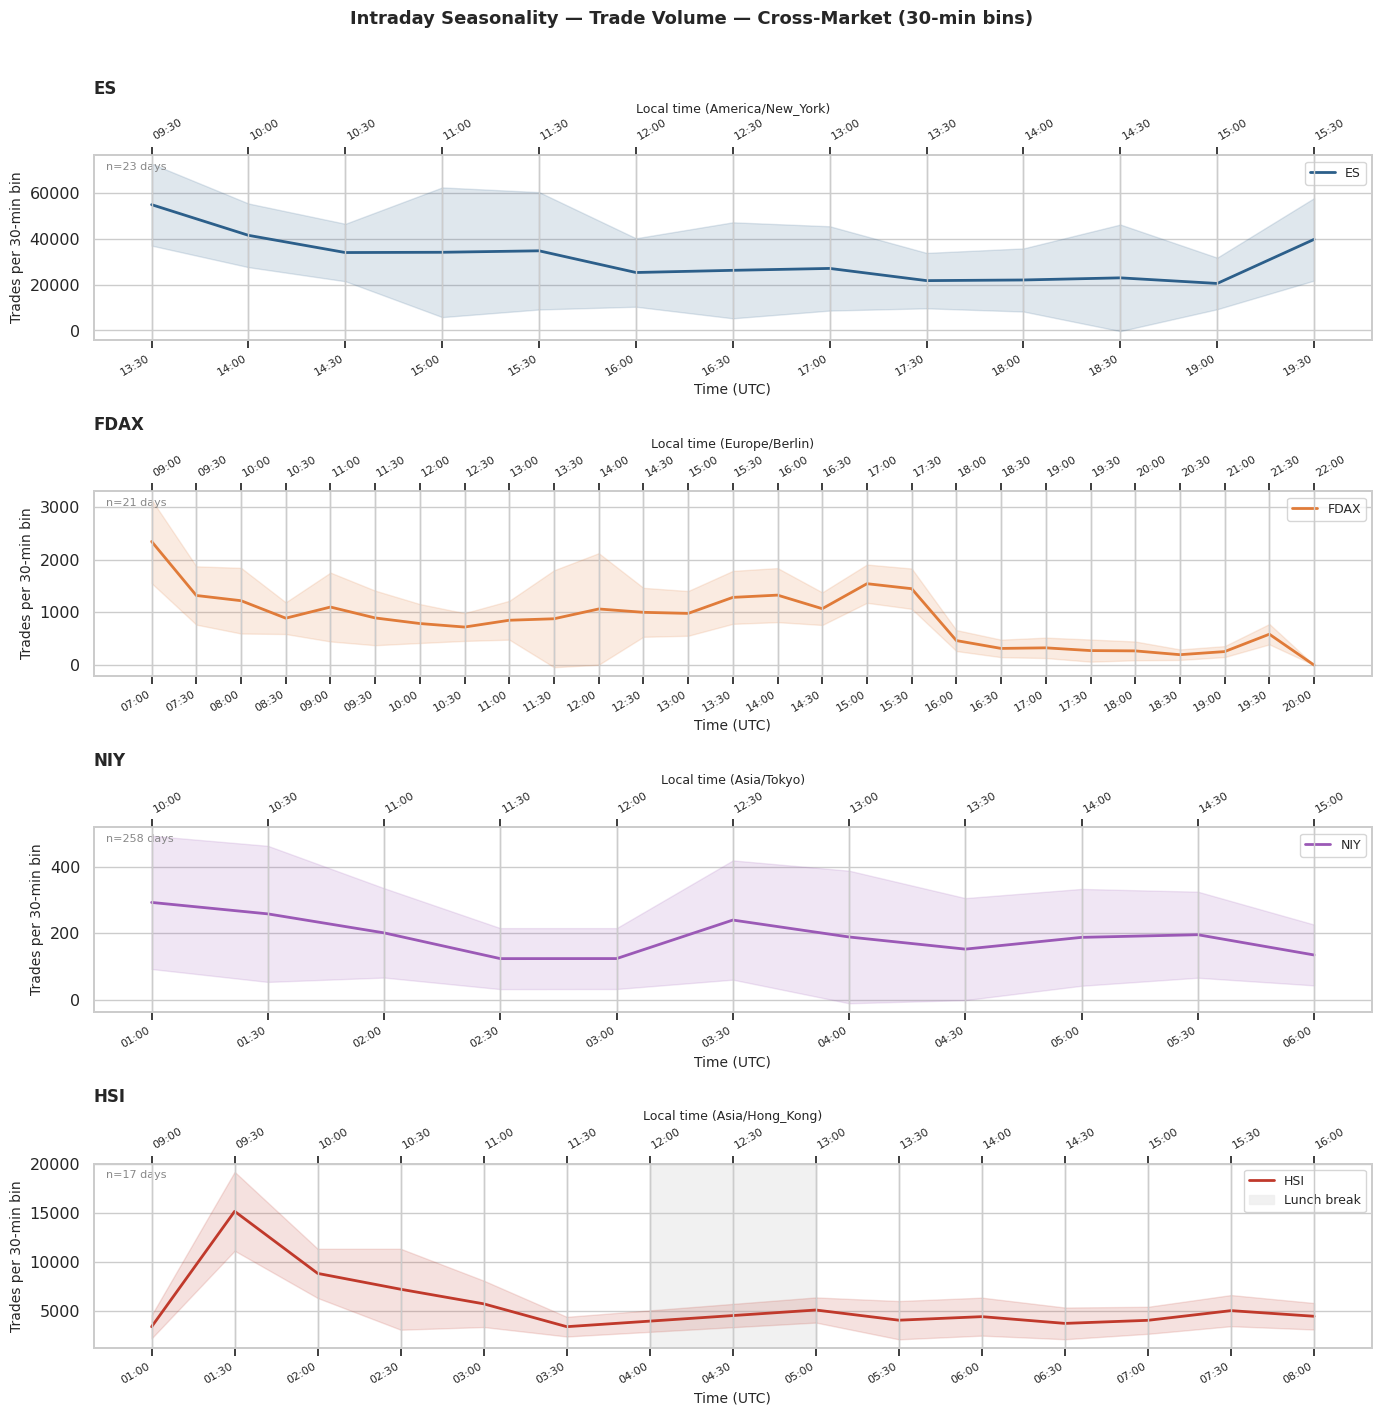

Saved: ../../reports/figures/04_intraday_seasonality/seasonality_otr_cross_market.png


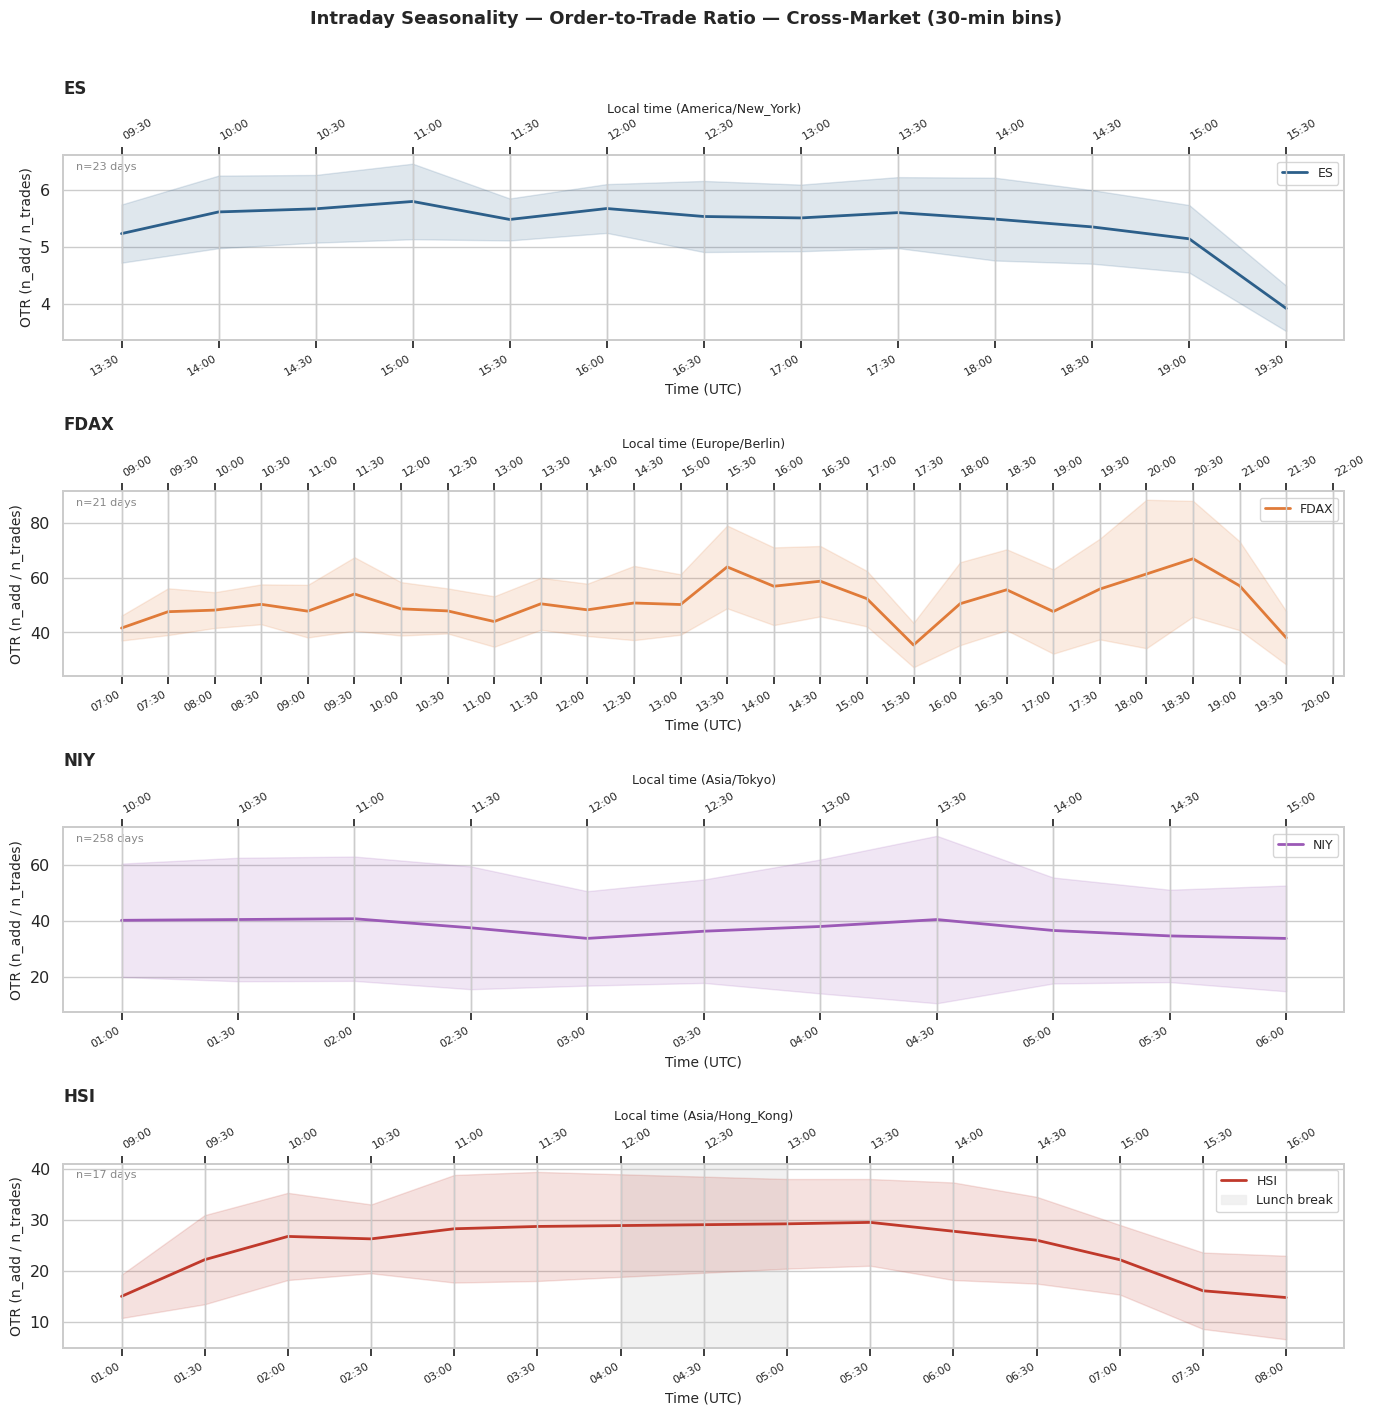

Saved: ../../reports/figures/04_intraday_seasonality/seasonality_spread_cross_market.png


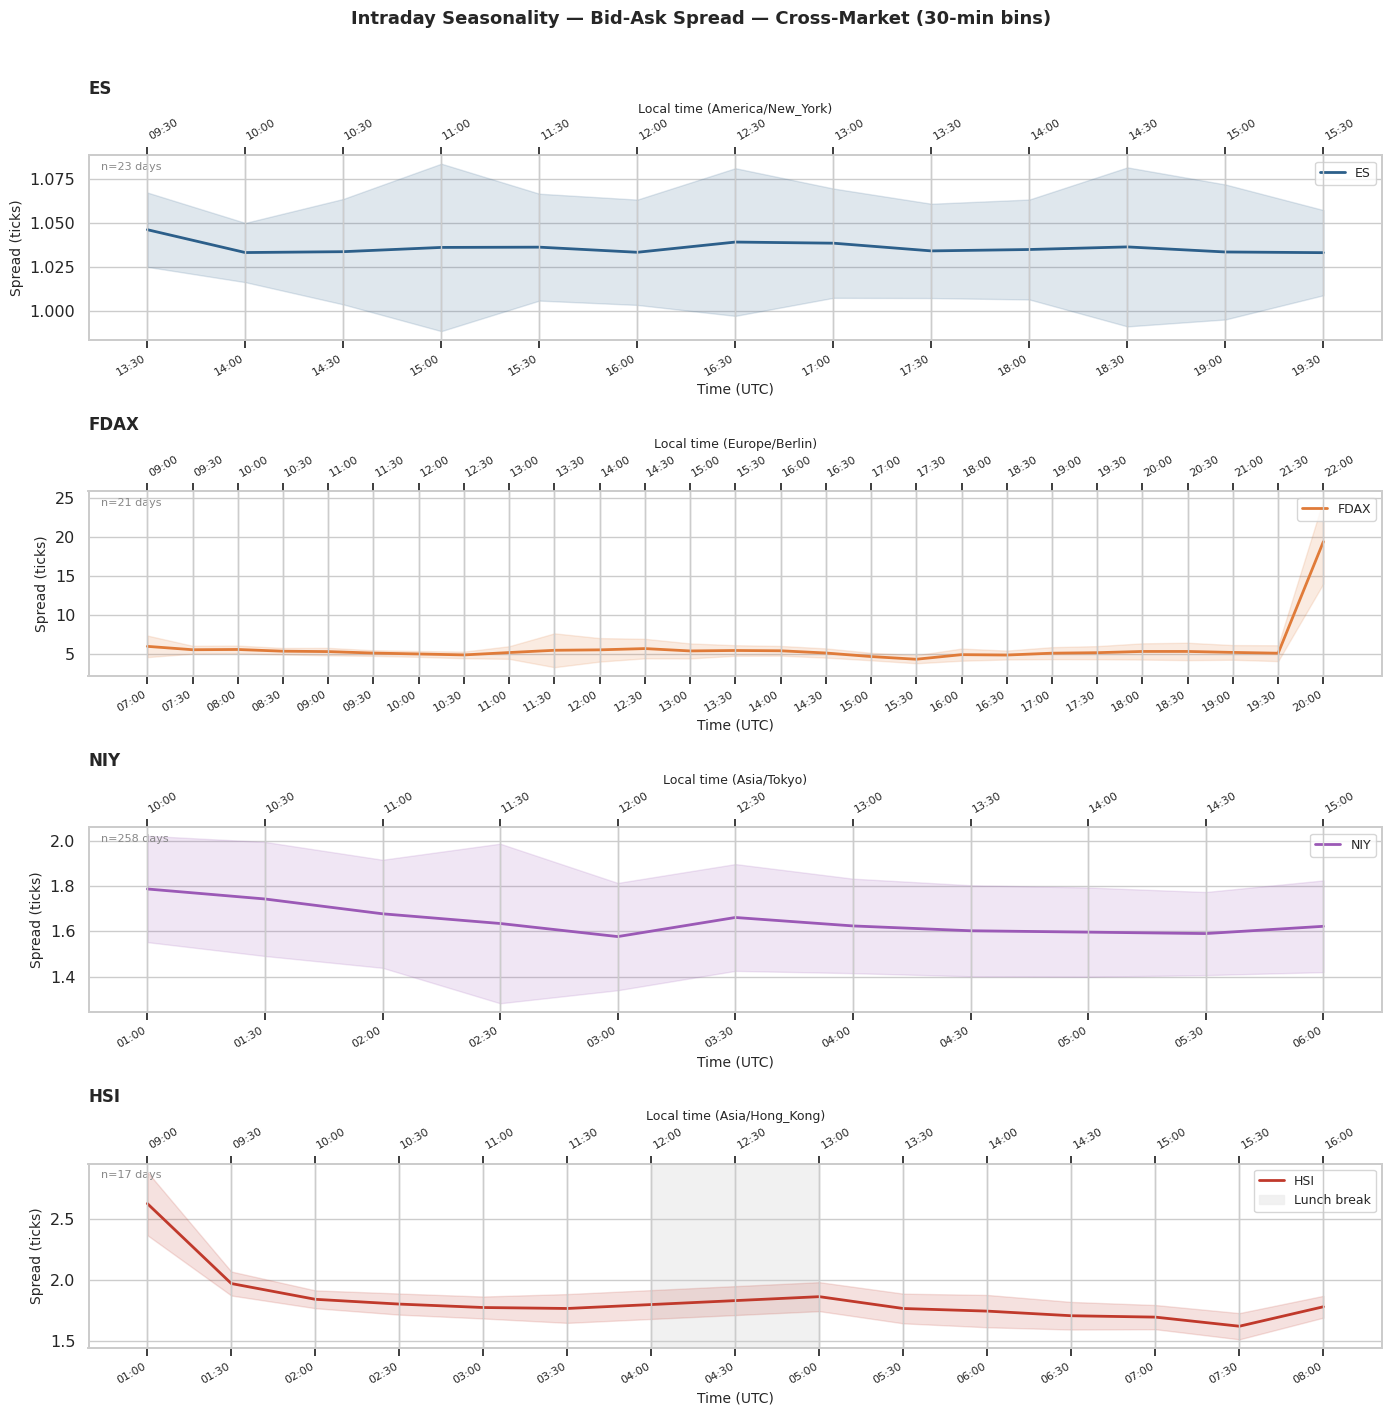

Saved: ../../reports/figures/04_intraday_seasonality/seasonality_depth_cross_market.png


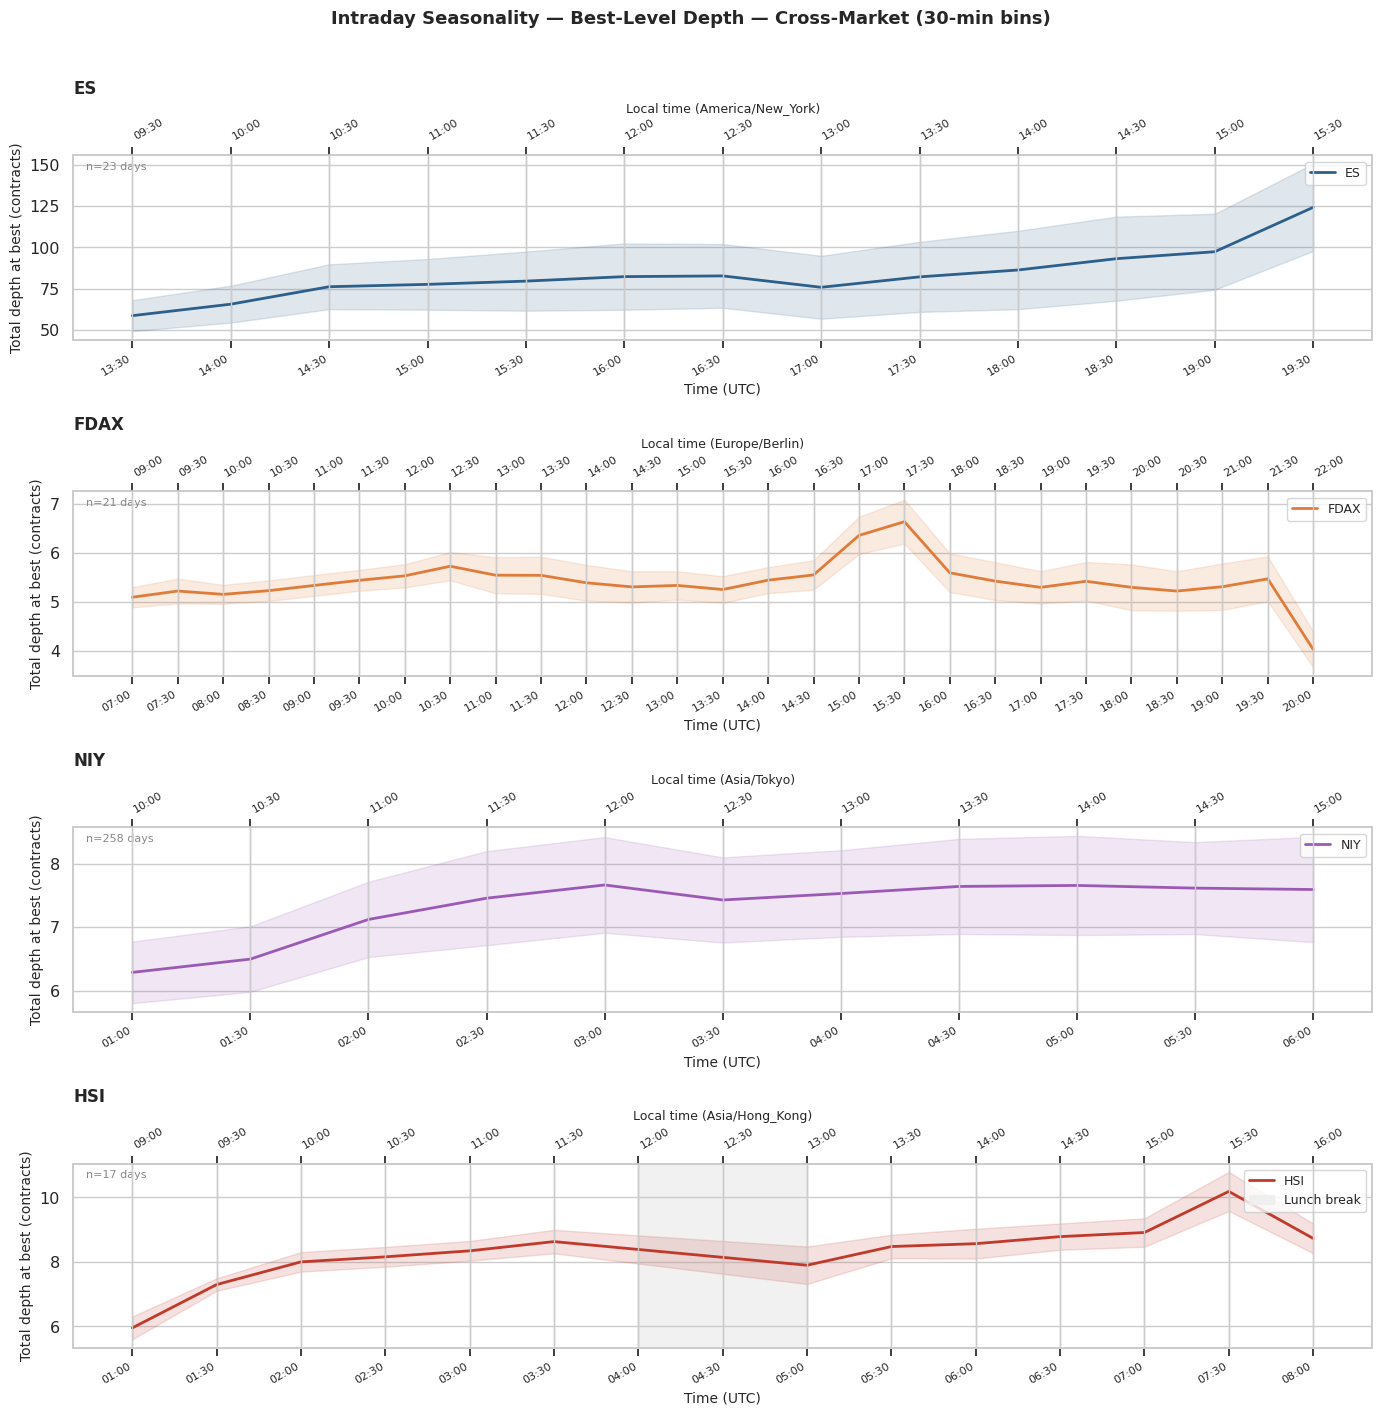

In [6]:
# HSI lunch break: 04:00-05:00 UTC = 240-300 minutes since midnight
HSI_LUNCH = (240, 300)

# Metric definitions: (profile_key, mean_col, std_col, ylabel, title_suffix, filename)
METRIC_DEFS = [
    (
        "volume", "n_trades_mean", "n_trades_std",
        "Trades per 30-min bin", "Trade Volume",
        "seasonality_volume_cross_market.png"
    ),
    (
        "otr", "otr_mean", "otr_std",
        "OTR (n_add / n_trades)", "Order-to-Trade Ratio",
        "seasonality_otr_cross_market.png"
    ),
    (
        "spread", "spread_mean", "spread_std_across_days",
        "Spread (ticks)", "Bid-Ask Spread",
        "seasonality_spread_cross_market.png"
    ),
    (
        "depth", "total_depth_mean", "bid_depth_std_across_days",
        "Total depth at best (contracts)", "Best-Level Depth",
        "seasonality_depth_cross_market.png"
    ),
]


for metric_key, mean_col, std_col, ylabel, title_suffix, filename in METRIC_DEFS:

    n = len(CROSS_MARKET_PRODUCTS)
    fig, axes = plt.subplots(n, 1, figsize=(14, 3.5 * n))
    if n == 1:
        axes = [axes]

    for ax, product in zip(axes, CROSS_MARKET_PRODUCTS):
        profile  = profiles[product][metric_key]
        info     = dr.get_info(product)
        tz_str   = info["local_tz"]
        cfg      = PRODUCT_CONFIG[product]
        ref_date = cfg["start"]    # representative date for DST resolution
        color    = PRODUCT_COLORS[product]

        # Compute x range from actual profile bins
        x_vals = [_time_to_minutes(t) for t in profile["time_bin"]]
        x_min, x_max = min(x_vals), max(x_vals)

        lunch = HSI_LUNCH if product == "HSI" else None

        plot_seasonality_panel(
            ax, profile, mean_col, std_col,
            label=product, color=color,
            show_ci=SHOW_CI, lunch_break=lunch
        )

        # UTC bottom axis
        format_utc_axis(ax, x_min, x_max, BIN_MINUTES)

        # Local time top axis
        add_local_time_axis(ax, tz_str, ref_date, x_min, x_max, BIN_MINUTES)

        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_title(product, fontsize=12, fontweight="bold", loc="left")
        ax.legend(loc="upper right", fontsize=9)

        # Annotate n_days
        n_days = profile["n_days"].max() if "n_days" in profile.columns else "?"
        ax.annotate(f"n={n_days} days", xy=(0.01, 0.92),
                    xycoords="axes fraction", fontsize=8, color="#888888")

    fig.suptitle(
        f"Intraday Seasonality — {title_suffix} — Cross-Market ({BIN_MINUTES}-min bins)",
        fontsize=13, fontweight="bold", y=1.01
    )
    plt.tight_layout()

    save_path = FIG_DIR / filename
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {save_path}")
    plt.show()

## 5. Build Profiles — EUREX Zoom (FDAX, FESX, FSMI)

In [7]:
EUREX_PRODUCTS = ["FDAX", "FESX", "FSMI"]

# FDAX already built above — only build FESX and FSMI if not already done
for product in EUREX_PRODUCTS:
    if product not in profiles:
        cfg = PRODUCT_CONFIG[product]
        print(f"\n--- {product} ({cfg['start']} → {cfg['end']}) ---")
        profiles[product] = build_intraday_profile(
            product,
            start=cfg["start"],
            end=cfg["end"],
            session=cfg["session"],
            verbose=False,
        )

print("EUREX profiles ready.")


--- FESX (2025-05-01 → 2025-06-01) ---

FESX: 21 days processed, 0 skipped

--- FSMI (2025-05-01 → 2025-06-01) ---

FSMI: 20 days processed, 1 skipped
EUREX profiles ready.


## 6. EUREX Comparison Plots

FDAX, FESX, and FSMI superimposed on the same axis — identical RTH window (07:00–21:00 UTC, n=21 days each), directly comparable.  

This comparison reveals the **EUREX liquidity gradient** across three products on the same venue:
- **FESX** (Euro Stoxx 50) — the reference product for European institutional equity exposure. High volume, deep book, tight spread.
- **FDAX** (DAX 40) — concentrated index (40 large-cap German stocks), favored by sophisticated algorithmic traders. Lower volume, thin book, wider spread.
- **FSMI** (SMI) — Swiss blue-chip index, lowest liquidity of the three. Mostly domestic institutional flow.

**Note on depth plot:** Y-axis is log-scaled. FESX best-level depth (~200–1800 contracts) is 2–3 orders of magnitude above FDAX (~5) and FSMI (~8–15). Linear scale would make FDAX and FSMI invisible.

Saved: ../../reports/figures/04_intraday_seasonality/seasonality_eurex_volume.png


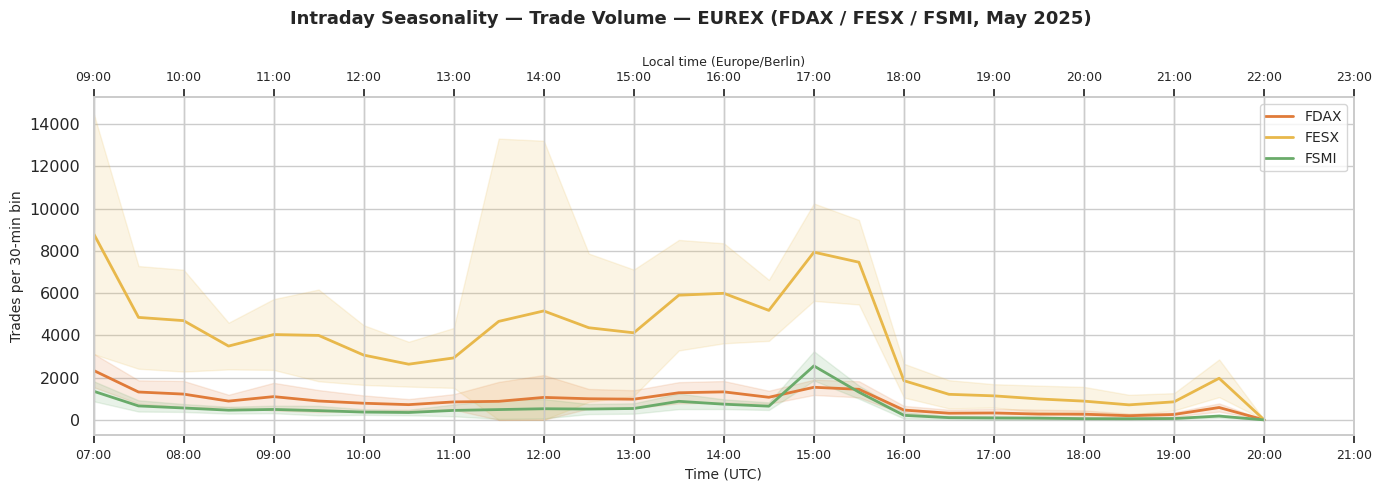

Saved: ../../reports/figures/04_intraday_seasonality/seasonality_eurex_otr.png


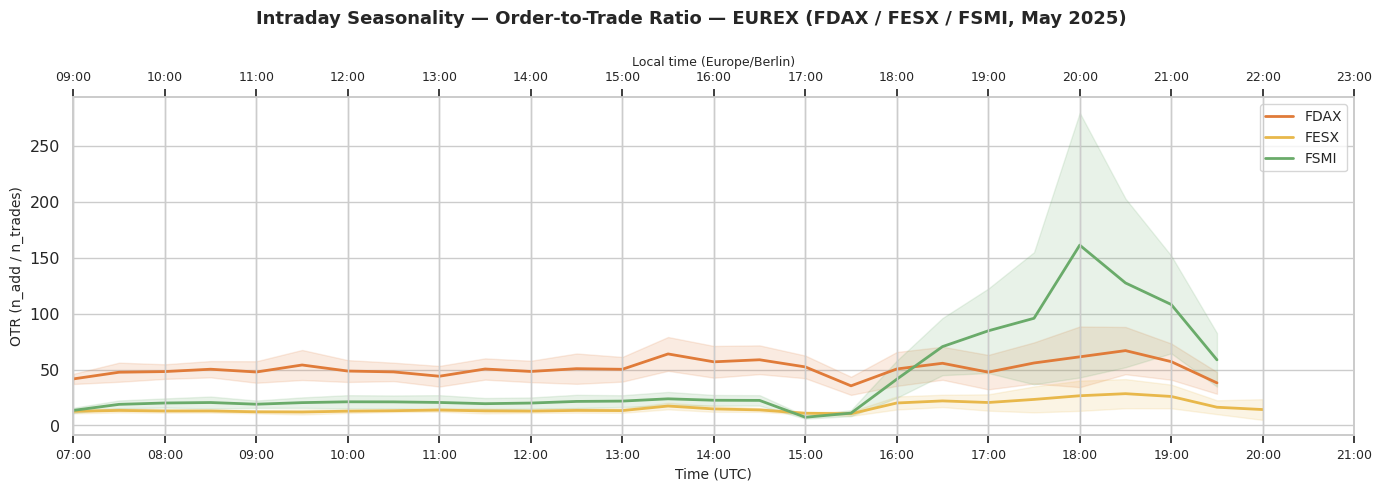

Saved: ../../reports/figures/04_intraday_seasonality/seasonality_eurex_spread.png


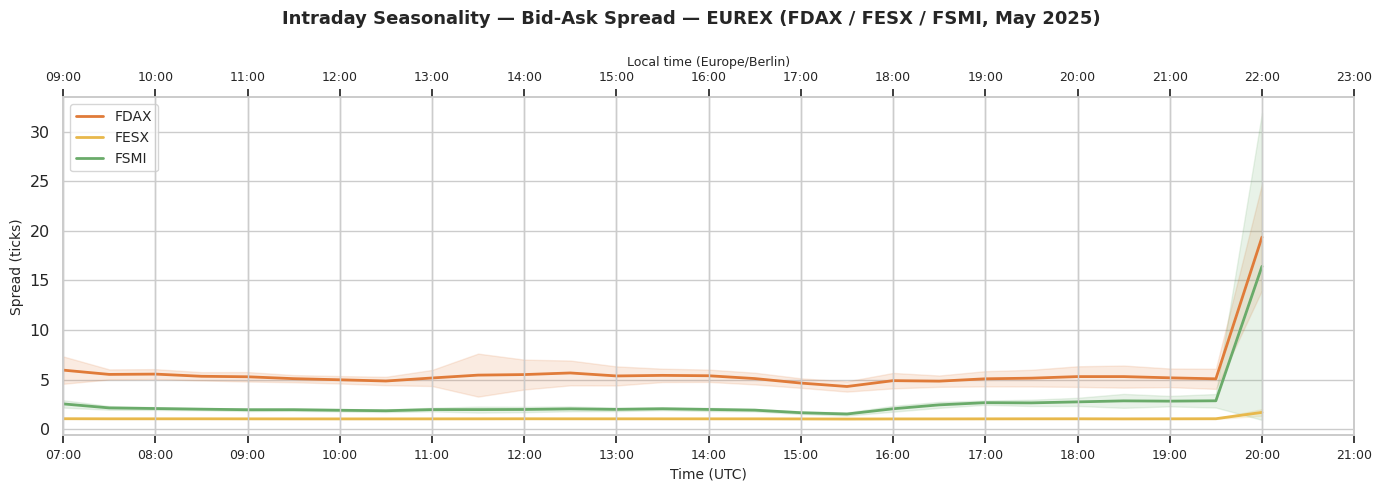

Saved: ../../reports/figures/04_intraday_seasonality/seasonality_eurex_depth.png


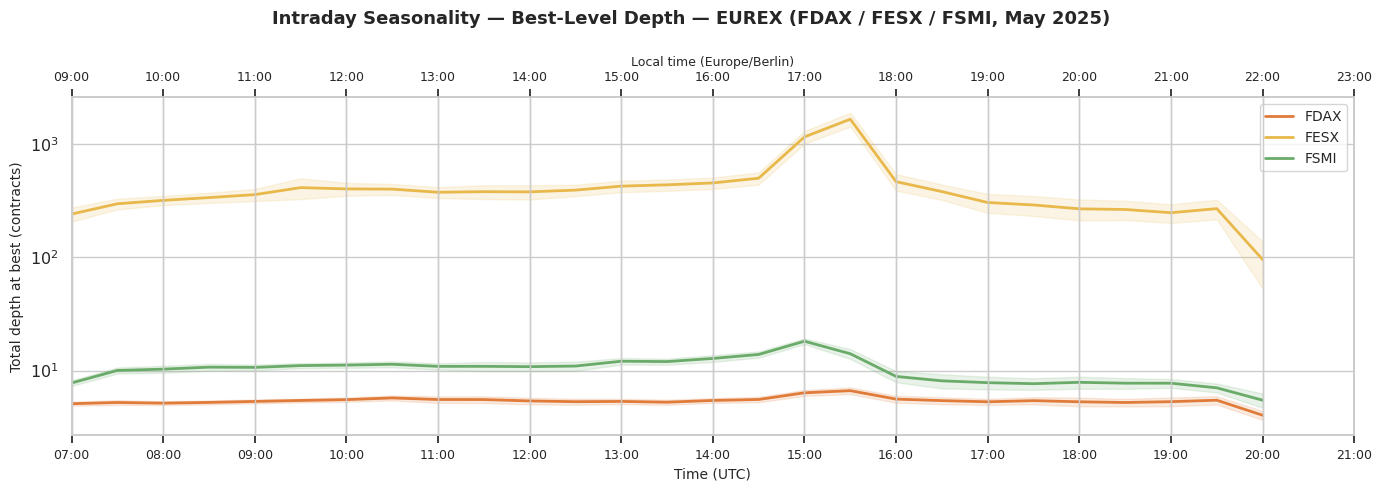

In [12]:
import numpy as np
# EUREX reference date for DST (all three share Europe/Berlin)
EUREX_TZ       = "Europe/Berlin"
EUREX_REF_DATE = PRODUCT_CONFIG["FDAX"]["start"]
EUREX_X_MIN    = 7 * 60     # 07:00 UTC
EUREX_X_MAX    = 21 * 60    # 21:00 UTC

for metric_key, mean_col, std_col, ylabel, title_suffix, _ in METRIC_DEFS:

    fig, ax = plt.subplots(figsize=(14, 5))

    for product in EUREX_PRODUCTS:
        profile = profiles[product][metric_key]
        y       = profile[mean_col].values
        std     = profile[std_col].values if std_col in profile.columns else None
        x       = [_time_to_minutes(t) for t in profile["time_bin"]]

        ax.plot(x, y, color=PRODUCT_COLORS[product], linewidth=2.0,
                label=product, zorder=2)

        # Log scale for depth — FESX peak (~1800) otherwise crushes FDAX (~5) and FSMI (~1)
        if metric_key == "depth":
            ax.set_yscale("log")
            ax.set_ylabel(f"{ylabel} (log scale)", fontsize=10)
        
        if SHOW_CI and std is not None:
            # Clip lower CI band to 0 — volume/count metrics cannot be negative
            ax.fill_between(x,
                            np.maximum(y - std, 0),   # floor at 0
                            y + std,
                            color=PRODUCT_COLORS[product],
                            alpha=CI_ALPHA, zorder=1)

    # --- UTC bottom axis: tick every 60min (readable on 14h session)
    utc_ticks  = list(range(EUREX_X_MIN, EUREX_X_MAX + 1, 60))
    utc_labels = [f"{int(x//60):02d}:{int(x%60):02d}" for x in utc_ticks]
    ax.set_xticks(utc_ticks)
    ax.set_xticklabels(utc_labels, fontsize=9, rotation=0)
    ax.set_xlabel("Time (UTC)", fontsize=10)
    ax.set_xlim(EUREX_X_MIN, EUREX_X_MAX)

    # --- Local time top axis: tick every 60min, aligned on UTC ticks
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(utc_ticks)
    local_labels = [_utc_to_local_label(x, EUREX_TZ, EUREX_REF_DATE) for x in utc_ticks]
    ax2.set_xticklabels(local_labels, fontsize=9, rotation=0)
    ax2.set_xlabel(f"Local time ({EUREX_TZ})", fontsize=9)

    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(fontsize=10)

    fig.suptitle(
        f"Intraday Seasonality — {title_suffix} — EUREX (FDAX / FESX / FSMI, May 2025)",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()

    save_path = FIG_DIR / f"seasonality_eurex_{metric_key}.png"
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {save_path}")
    plt.show()

## 7. Findings

---

### 7.1 Volume — J-shaped profile across all markets, but with different drivers

All four products show a **J-shaped volume profile**: a peak at the open, a trough in mid-session, and a pick-up at the close. However the shape and magnitude differ markedly.

**ES** shows the sharpest open (13:30 UTC = 09:30 ET, ~57K trades/30min) followed by a steady decline to ~21K at 18:00 UTC, then a closing pick-up to ~40K at 19:30 UTC. The opening peak is driven by the NYSE open — retail and institutional flow arriving simultaneously creates a burst of activity. The large confidence band reflects significant day-to-day variation (event-driven days vs quiet days).

**FDAX** has a more pronounced opening spike (07:00 UTC = 09:00 CET, ~2.5K trades/30min) that drops sharply by 08:00, then stabilises at ~1K for most of the European session. A secondary pick-up is visible at 13:30 UTC (09:30 ET) as US participants join — a classic cross-market interaction. The absolute volume (~1K–2.5K) is an order of magnitude below ES, consistent with FDAX's role as a pure institutional product.

**NIY** shows the flattest volume profile of all four products — remarkably stable at ~150–250 trades/30min throughout the OSE asia session (01:00–06:15 UTC). There is no equivalent of the NYSE open catalyst within this window; the session is dominated by steady Japanese institutional flow. The wide confidence band (n=258 days) captures significant regime variation across 2025 (see rolling OTR analysis), but the intraday *shape* is stable.

**HSI** exhibits the sharpest intraday pattern: a very strong spike at 01:30 UTC (09:30 HKT, ~15K trades/30min) — the Hong Kong cash market open — followed by a steep decline to ~4K by 03:00 UTC. Post-lunch (05:00 UTC), volume stabilises at ~4–5K with a slight pick-up toward the close. The lunch break gap (04:00–05:00 UTC, grey shading) is clean and clearly visible.

---

### 7.2 OTR — Inverse relationship with volume, but structurally different across zones

The OTR intraday profile confirms a robust finding: **OTR and volume are inversely related within a session**. When traded volume is high, the ratio of order submissions to executions falls — more participants are willing to cross the spread, reducing the proportion of quotes that expire without execution.

**ES** shows a mild but consistent OTR decline from ~6 at the open to ~4 at the close (19:30 UTC). These are very low values — ES is the most directionally efficient market in our universe with the new FILL-based definition. The flat profile confirms that ES is always in a high-flow state relative to quote activity.

**FDAX** holds a steady OTR of ~40–55 throughout the session, with a slight increase toward the close. This confirms the picture from our cross-market summary: FDAX has a persistently high algorithmic quoting rate regardless of time-of-day. The market maker population on FDAX is always actively quoting and cancelling.

**NIY** shows the flattest OTR profile (~35–40), consistent with its flat volume profile. The OSE session has no intraday catalyst that would shift the ratio — it is a steady-state market making regime throughout the window. The wide confidence interval reflects regime variation across the year rather than intraday instability.

**HSI** shows an unusual **inverted-U OTR profile**: rising from ~15 at the open to ~28 in mid-session, then falling back to ~15 at the close. This is the opposite of what the inverse-volume hypothesis predicts. The explanation: at the open (01:15 UTC) the book is fresh and flow is directional (the cash open spike) — OTR is low because traders are executing, not quoting. As directional flow subsides, market makers dominate and OTR rises. The evening session sees renewed directional activity, pushing OTR back down.

---

### 7.3 Spread — Tighter than expected on most markets, with a dramatic end-of-session effect on EUREX

**ES** maintains a near-constant spread of **~1.03 ticks** throughout the entire session (13:30–19:30 UTC). The intraday variation is minimal (confidence band spans ~1.00–1.07 ticks). This is a defining characteristic of the world's most liquid equity index future: the spread is structurally pinned at 1 tick by intense HFT competition. There is essentially no intraday spread seasonality to exploit on ES.

**FDAX** holds at **~5 ticks** through most of the session (07:00–19:30 UTC), then explodes to ~20 ticks at the close (19:30–20:00 UTC). Five ticks on FDAX = 5 × €12.5 = **€62.50 per contract** of spread cost — meaningful on a ~€550K notional contract but modest in relative terms (~0.011%). The end-of-session spike reflects the well-known liquidity withdrawal before the electronic session closes: market makers pull their quotes, and the remaining orders create a wide spread.

**NIY** shows a mild spread compression from **~1.8 ticks** at the open to ~1.6 ticks in mid-session. This is a small but consistent pattern, suggesting that liquidity improves as the OSE session matures and more participants become active.

**HSI** shows a **decreasing spread profile** from ~2.5 ticks at the open (01:15 UTC) to ~1.6 ticks by the close (08:00 UTC). This is the most pronounced intraday spread pattern in our cross-market sample — and it runs counter to the typical U-shape. The declining spread through the session reflects the gradual build-up of liquidity as more HK participants join after the initial open activity. The lunch break creates a small discontinuity but the overall trend is maintained post-lunch.

---

### 7.4 Depth — Counter-intuitive patterns that reveal market structure

Depth at the best level is the most informative metric for execution planning — it determines how much size can be executed without market impact.

**ES** shows a **steadily increasing depth** from ~55 contracts at the open to ~125 contracts at the close. This is counter-intuitive at first glance — one might expect depth to collapse at the open when adverse selection risk is highest. The explanation is structural: ES market makers post very small sizes at the best and replenish continuously. As the session progresses and uncertainty resolves, they gradually increase their posted size. The BBO change filter is crucial here — without it, the monotonic increase would be masked by noise.

**FDAX** maintains a near-flat depth of **~5 contracts** throughout the session, with a small peak at 15:30 UTC (US open). Five contracts at ~€550K each = ~€2.75M of immediately available liquidity at the best. This is thin by any measure — FDAX is a quote-and-cancel market where the book is constantly recycled but never deep. The flatness confirms that depth is not a time-of-day phenomenon on FDAX; it is a structural property of the market.

**NIY** shows a gradual depth increase from **~6.3 to ~7.5 contracts** (01:00–03:00 UTC), stabilising through the remainder of the session. Small absolute values consistent with a medium-liquidity market. The OSE session open is associated with lower depth (book is being established post-Itayose auction); depth recovers as order flow normalises.

**HSI** shows a **gradual depth increase** from ~6 contracts at the open to ~10 contracts by 07:30 UTC, with a small spike around 03:00 UTC. The lunch break creates a visible dip. Overall pattern similar to ES — depth builds through the session as market makers increase commitment. Post-lunch depth recovers quickly, confirming that the reconstruction pipeline is now clean.

---

### 7.5 EUREX zoom — Three products, three microstructure regimes

The EUREX comparison is one of the most striking results in this analysis. Despite sharing the same venue, session hours, clearing infrastructure, and regulatory framework, FDAX, FESX, and FSMI exhibit **fundamentally different microstructure regimes**.

**The FESX depth anomaly at 15:30 UTC** is the standout finding. Depth surges from ~300 contracts in mid-session to a peak of ~1800 contracts at 15:30 UTC (09:30 ET, NYSE open), before collapsing back to ~400 by 16:00 UTC. FDAX shows no equivalent effect (~5–7 contracts throughout). The interpretation: FESX is the primary instrument used by US institutional investors to hedge or gain European equity exposure. At the NYSE open, US participants add significant passive liquidity on FESX — creating a 30-minute window of exceptional depth. This effect is absent on FDAX because FDAX is predominantly traded by European participants with less connection to the US open timing. This is a **cross-market microstructure interaction** that has direct implications for execution strategy: the optimal time to execute large FESX orders is the 15:00–16:00 UTC window.

**The OTR ordering reverses expectations.** FDAX has the highest OTR (~40–60), FSMI is intermediate (~15–25 in the main session), and FESX the lowest (~10–20). One would naively expect the most liquid product (FESX) to have the highest algorithmic activity. The reverse is true: FESX has such deep liquidity and tight spreads that market makers do not need to constantly refresh their quotes — they can post large passive orders and wait. FDAX's thin book requires constant quote management to avoid being adversely selected, driving a higher OTR. FSMI's end-of-session OTR explosion (~100–160 at 18:00–19:30 UTC) is a thin-market artefact: very few trades with many orders still being managed, ratio becomes unstable.

**The spread ordering is as expected** but the absolute values are informative. FESX at ~1 tick throughout the session confirms it as the most liquid EUREX product for institutional execution. FSMI at ~2 ticks is surprisingly competitive given its low volume. FDAX at ~5 ticks is the most expensive to trade on a per-tick basis — but the spread is remarkably stable from 07:00 to 19:30 UTC, making FDAX predictable for cost modeling. The end-of-session spread explosion (all three products, ~20:00 UTC) marks the liquidity withdrawal before session close — a universal EUREX phenomenon.

---

### 7.6 Key takeaways for Destiny Trading

These intraday profiles are not merely descriptive — they have direct operational implications:

1. **Avoid the first and last 30 minutes** for strategy evaluation. Volume, spread, and depth are all atypical at session boundaries. OFI signals computed in these windows will have different IC profiles than mid-session.
2. **FESX 15:00–16:00 UTC** is a unique execution window: depth is 4–6× higher than baseline. Large orders should be timed to this window when possible.
3. **ES spread is constant** — no time-of-day adjustment needed for spread-based cost models on ES.
4. **HSI spread decreases through the session** — the afternoon session (post-lunch, 05:00–08:00 UTC) is systematically cheaper to trade than the morning.
5. **NIY intraday pattern is flat** — no strong time-of-day effect within the asia session. Signals should be evaluated uniformly across the window.

## 8. Open Questions and Next Steps

### Immediate follow-up (within Axis 1)

- **Common date cross-market comparison:** profiles currently use different date ranges per product (ES: Oct 2025, EUREX: May 2025, NIY: full 2025, HSI: Feb 2026). This limits direct cross-market comparison. Once the common dataset (ES + HKEX May 2025) is purchased, rerun `build_intraday_profile` with a single reference month for all products.
- **NIY US session:** run `build_intraday_profile('NIY', session='us')` and compare the asia vs US intraday profiles on the same product. The US session (13:30–20:00 UTC) has a very different participant base — we expect a much more pronounced volume seasonality driven by the NYSE open, and a different OTR regime.
- **FSMI OTR end-of-session:** the OTR explosion on FSMI after 18:00 UTC has a very wide CI and is likely a thin-market artefact. Investigate whether a minimum n_fill threshold per bin would stabilise the profile without losing genuine signal.
- **Save aggregated profiles to Parquet:** the `build_intraday_profile()` computation takes several minutes per product. Once validated, serialize the output DataFrames to `data/features/intraday_seasonality/` so the notebook can reload instantly without rerunning the full pipeline.

### Axis 2 — Order Flow Imbalance (next)

The intraday seasonality establishes the **baseline** for all subsequent signal research. Key implications for OFI:
- OFI computed at 13:30 UTC on ES competes against open-auction noise — its IC at that time should be benchmarked against the intraday baseline, not the daily average.
- The inverse OTR/volume relationship suggests that OFI alpha may decay faster during high-volume bins (more informed participants, faster price discovery) than during low-volume bins (market making dominated).
- The FESX depth anomaly at 15:30 UTC may create a temporary OFI signal as passive liquidity is added and then withdrawn — worth examining.

### Longer term

- **Intraday seasonality as a real-time feature:** the deviation of current spread/depth/volume from the expected seasonal level is a conditioning signal for Destiny Trading. A spread 3× above its typical seasonal level indicates abnormal conditions — potential adverse selection, pending news, or illiquidity event. This is a direct input to the Avellaneda-Stoikov market making inventory model.
- **MBP-10 depth profile:** the current analysis is limited to the best level (MBP-1). With MBP-10, the total depth within N ticks provides a more operationally relevant liquidity measure for large order sizing.
- **Cross-product depth correlation on EUREX:** the FESX depth spike at 15:30 UTC is not mirrored on FDAX or FSMI. Quantifying the correlation structure of depth across EUREX products could reveal execution opportunities (e.g., routing large orders to the deepest product at each point in the session).